# Split EDA — Train / Validation / Test

`eda/split_validation.py`가 만든 **train(90%) / validation(10%)** 분할과 **test**를 나란히 놓고,
검증 세트가 train·test와 같은 분포인지 확인한다. (dev는 의도적으로 모호한 문항 집합이라 여기서는 제외. dev 분석은 `text_eda_vqa.ipynb`)

| 순서 | 항목 | 보는 것 |
|---|---|---|
| 1 | 정답 개수 분포 | a/b/c/d 비율 (test는 정답 없음) |
| 2 | 종횡비 및 픽셀 분포 | aspect ratio, megapixels, 해상도 조합, 방향 |
| 3 | 밝기/대비/HSV 분포 | brightness, contrast, H/S/V 평균 |
| 4 | 질문/선지 길이 분포 | 질문 글자·어절 수, 보기 평균·최대 글자 수, 전체 프롬프트 길이 |
| 5 | 질문 유형 분포 | `common.question_type` 규칙 기반 유형 비율 |

경로: 원본 `data/raw/`, 분할 `data/split/`. 분할 파일이 없으면 첫 셀이 만든다.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

ROOT = Path.cwd() if (Path.cwd() / "eda").is_dir() else Path.cwd().parent   # repo root 또는 eda/ 에서 실행
sys.path.insert(0, str(ROOT / "eda"))
from common import CHOICES, question_type, text_metrics, ks_statistic
from split_validation import ensure_split

RAW_DIR   = ROOT / "data" / "raw"
SPLIT_DIR = ROOT / "data" / "split"
TABLES    = ROOT / "eda" / "tables"

split_paths = ensure_split(RAW_DIR, SPLIT_DIR)     # 없으면 분할, 있으면 skip
print(json.loads(split_paths["meta"].read_text(encoding="utf-8")))

frames = {
    "train":      pd.read_csv(split_paths["train"]),
    "validation": pd.read_csv(split_paths["validation"]),
    "test":       pd.read_csv(RAW_DIR / "test.csv"),
}
SPLITS = list(frames)
for name, df in frames.items():
    print(f"{name:<11s} {len(df):>5d} rows")

# 팔레트: split 마다 고정 색 (순서 바뀌어도 색은 유지)
COLORS = {"train": "#2a78d6", "validation": "#eb6834", "test": "#1baf7a"}
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.unicode_minus": False})
# 한글 폰트가 있으면 사용 (없으면 차트 라벨은 영문 매핑을 씀)
from matplotlib import font_manager
_ko = [f.name for f in font_manager.fontManager.ttflist if any(k in f.name for k in ("Nanum", "Noto Sans CJK", "Malgun", "AppleGothic", "Apple SD Gothic"))]
if _ko:
    plt.rcParams["font.family"] = _ko[0]
print("한글 폰트:", _ko[0] if _ko else "없음 (차트는 영문 라벨)")

[split] skip: 이미 존재 → /home/lys74/DEV/scene-text-vision-repo/data/split (train 6043 | validation 671)
{'seed': 42, 'fraction': 0.1, 'n_train_original': 6714, 'n_train': 6043, 'n_validation': 671, 'n_image_groups': 6705, 'n_multi_image_groups': 9, 'answer_ratio_train': {'a': 0.2534, 'b': 0.2449, 'c': 0.2555, 'd': 0.2462}, 'answer_ratio_validation': {'a': 0.2519, 'b': 0.2444, 'c': 0.2563, 'd': 0.2474}, 'created': '2026-09-23 21:20:47'}
train        6043 rows
validation    671 rows
test         6714 rows
한글 폰트: 없음 (차트는 영문 라벨)


## 공용 함수

- `hist3`: 세 split 을 같은 축에 밀도 히스토그램으로 겹쳐 그림 (상위 0.5% 는 잘라서 축이 깨지지 않게)
- `share_table`: 범주 비율(%) 표
- `shift_table`: validation 이 train·test 와 얼마나 다른지 — KS 통계량과 SMD(표준화 평균 차이). |SMD| < 0.1, KS < 0.05 면 사실상 같은 분포

In [2]:
def hist3(feature, bins=50, clip_q=0.995, title=None, xlabel=None, ax=None, log=False):
    ax = ax or plt.subplots(figsize=(9, 4))[1]
    values = pd.concat([frames[s][feature] for s in SPLITS]).dropna()
    lo, hi = values.quantile(1 - clip_q), values.quantile(clip_q)
    edges = np.linspace(lo, hi, bins + 1)
    for s in SPLITS:
        v = frames[s][feature].dropna().clip(lo, hi)
        ax.hist(v, bins=edges, density=True, histtype="step", linewidth=2, color=COLORS[s], label=f"{s} (n={len(v)})")
        ax.hist(v, bins=edges, density=True, alpha=0.12, color=COLORS[s])
    if log:
        ax.set_yscale("log")
    ax.set_title(title or feature); ax.set_xlabel(xlabel or feature); ax.set_ylabel("density"); ax.legend(frameon=False)
    return ax


def share_table(column, order=None):
    table = pd.concat({s: frames[s][column].value_counts(normalize=True) for s in SPLITS}, axis=1).fillna(0)
    if order is not None:
        table = table.reindex(order).fillna(0)
    return (table * 100).round(2).rename_axis(column)


def smd(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((b.mean() - a.mean()) / pooled) if pooled else 0.0


def shift_table(features):
    rows = []
    for f in features:
        v = frames["validation"][f].dropna()
        row = {"feature": f}
        for s in ("train", "test"):
            o = frames[s][f].dropna()
            row[f"SMD(valid-{s})"] = round(smd(o, v), 4)
            row[f"KS(valid,{s})"]  = round(ks_statistic(o, v), 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index("feature")


def bar_shares(table, title, ax=None, rotate=0):
    ax = ax or plt.subplots(figsize=(10, 4))[1]
    table[SPLITS].plot(kind="bar", ax=ax, color=[COLORS[s] for s in SPLITS], width=0.8, edgecolor="none")
    ax.set_title(title); ax.set_ylabel("%"); ax.legend(frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=rotate, ha="right" if rotate else "center")
    return ax

## 1. 정답 개수 분포

train / validation 의 `answer` 비율. test 에는 정답이 없으므로 표에 `—` 로 둔다.
분할이 정답별로 층화되었으므로 두 비율은 거의 같아야 한다.

count            share %                
       train validation   train validation test
answer                                         
a       1531        169   25.34      25.19    —
b       1480        164   24.49      24.44    —
c       1544        172   25.55      25.63    —
d       1488        166   24.62      24.74    —

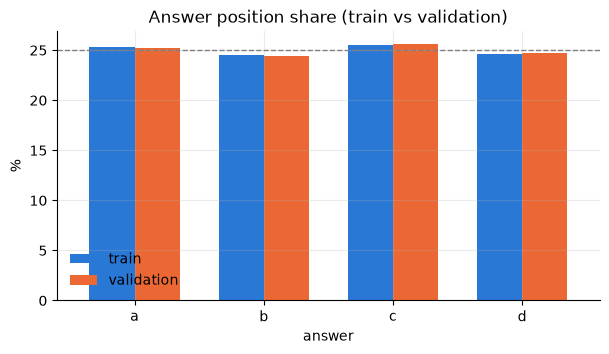

In [3]:
answer_counts = pd.DataFrame({
    s: frames[s]["answer"].str.strip().str.lower().value_counts().reindex(CHOICES).fillna(0).astype(int)
    for s in ("train", "validation")
}).rename_axis("answer")
answer_share = (answer_counts / answer_counts.sum() * 100).round(2)
answer_share["test"] = "—"
display(pd.concat({"count": answer_counts, "share %": answer_share}, axis=1))

fig, ax = plt.subplots(figsize=(7, 3.5))
(answer_counts / answer_counts.sum() * 100).plot(kind="bar", ax=ax, color=[COLORS["train"], COLORS["validation"]], width=0.7, edgecolor="none")
ax.axhline(25, color="gray", linewidth=1, linestyle="--"); ax.set_ylabel("%"); ax.set_title("Answer position share (train vs validation)")
ax.legend(frameon=False); plt.setp(ax.get_xticklabels(), rotation=0); plt.show()

## 이미지 지표 계산 (2·3절 공용)

세 split 의 모든 이미지를 한 번 읽어 크기·밝기·대비·HSV 평균을 구한다. 결과는 `eda/tables/split_image_metrics.csv` 에 캐시하고, 다음부터는 캐시를 읽는다.
JPEG draft 모드로 1/4 크기 디코딩 후 256px 썸네일에서 계산하므로 16k 장에 1~2분이면 끝난다.

- `brightness` = 그레이스케일 평균 (0~1), `contrast` = 그레이스케일 표준편차
- `hue_mean` = 채도가 있는 픽셀(S>0.1)의 원형 평균 hue (도, 0~360), `sat_mean` / `val_mean` = HSV S·V 평균 (0~1)

In [4]:
def image_row(path: Path):
    with Image.open(path) as im:
        width, height = im.size                      # EXIF 회전 전 저장된 크기 (모델도 이 크기를 봄)
        im.draft("RGB", (width // 4, height // 4))   # JPEG 만 적용, 빠른 디코딩
        rgb = ImageOps.exif_transpose(im).convert("RGB")
        rgb.thumbnail((256, 256))
        hsv = np.asarray(rgb.convert("HSV"), dtype=np.float32) / 255.0
        gray = np.asarray(rgb.convert("L"), dtype=np.float32) / 255.0
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    mask = s > 0.1
    if mask.any():
        ang = h[mask] * 2 * np.pi
        hue = (np.degrees(np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())) + 360) % 360
    else:
        hue = np.nan
    return {"width": width, "height": height, "megapixels": width * height / 1e6, "aspect_ratio": width / height,
            "brightness": float(gray.mean()), "contrast": float(gray.std()),
            "hue_mean": float(hue), "sat_mean": float(s.mean()), "val_mean": float(v.mean())}


IMAGE_COLS = ["width", "height", "megapixels", "aspect_ratio", "brightness", "contrast", "hue_mean", "sat_mean", "val_mean"]
cache_path = TABLES / "split_image_metrics.csv"
all_ids = pd.concat([frames[s][["id", "path"]] for s in SPLITS], ignore_index=True)

if cache_path.exists() and set(pd.read_csv(cache_path, usecols=["id"])["id"]) >= set(all_ids["id"]):
    metrics = pd.read_csv(cache_path)
    print("cache:", cache_path, len(metrics), "rows")
else:
    import time
    records, t0 = [], time.time()
    for i, r in enumerate(all_ids.itertuples(index=False), 1):
        records.append({"id": r.id, **image_row(RAW_DIR / r.path)})
        if i % 2000 == 0 or i == len(all_ids):
            print(f"  images {i}/{len(all_ids)} ({time.time() - t0:.0f}s)", flush=True)
    metrics = pd.DataFrame(records).round(4)
    TABLES.mkdir(parents=True, exist_ok=True)
    metrics.to_csv(cache_path, index=False)
    print("saved:", cache_path)

metrics = metrics.set_index("id")
for s in SPLITS:
    frames[s] = frames[s].drop(columns=[c for c in IMAGE_COLS if c in frames[s].columns]).join(metrics[IMAGE_COLS], on="id")
    assert frames[s][IMAGE_COLS].notna().drop(columns=["hue_mean"]).all().all(), f"{s}: 이미지 지표 누락"
    frames[s]["orientation"] = np.select([frames[s]["aspect_ratio"] > 1.05, frames[s]["aspect_ratio"] < 0.95], ["landscape", "portrait"], "square")

  images 2000/13428 (3s)


  images 4000/13428 (7s)


  images 6000/13428 (10s)


  images 8000/13428 (13s)


  images 10000/13428 (17s)


  images 12000/13428 (20s)


  images 13428/13428 (21s)


saved: /home/lys74/DEV/scene-text-vision-repo/eda/tables/split_image_metrics.csv


## 2. 종횡비 및 픽셀 분포

- `aspect_ratio` = width / height (1 미만이면 세로 사진)
- `megapixels` = width × height / 10⁶
- 해상도 조합 상위 10개와 방향(portrait / landscape / square) 비율

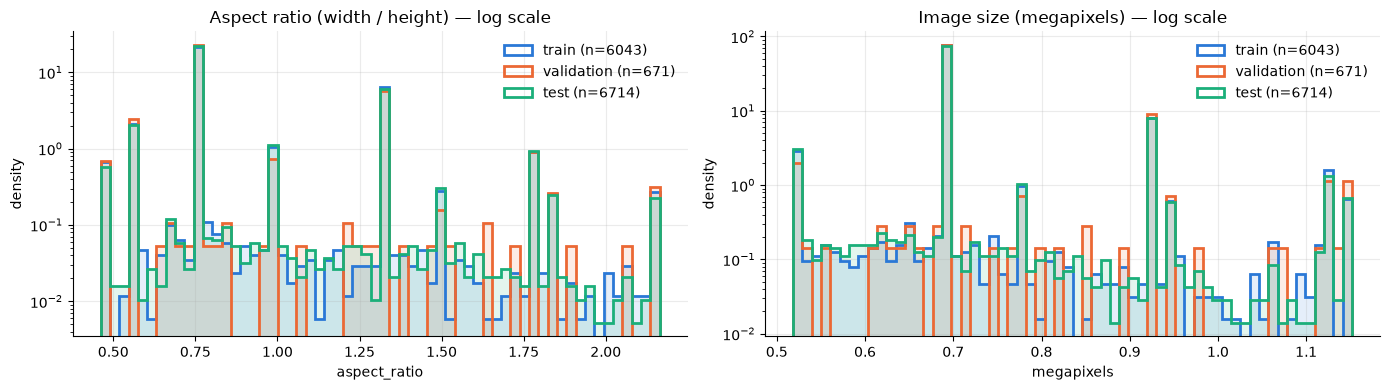

train                             validation           \
                 mean      50%      min       max       mean      50%   
width         800.658  720.000  720.000  3033.000    796.744  720.000   
height        921.935  960.000  720.000  2054.000    934.116  960.000   
megapixels      0.722    0.691    0.518     2.184      0.728    0.691   
aspect_ratio    0.917    0.750    0.350     4.212      0.901    0.750   

                                    test                              
                  min       max     mean      50%      min       max  
width         720.000  2266.000  798.795  720.000  720.000  3394.000  
height        720.000  1845.000  921.332  960.000  720.000  3103.000  
megapixels      0.518     1.632    0.720    0.691    0.518     2.444  
aspect_ratio    0.390     3.147    0.914    0.750    0.232     4.714

해상도 조합 상위 10개 (%)


,train,validation,test
W×H,,,
720×960,61.15,63.64,62.03
960×720,18.04,16.10,16.88
720×1280,2.93,3.73,2.67
720×720,2.88,2.09,3.10
720×1279,2.80,2.98,2.96
1280×720,1.22,1.64,1.24
1279×720,1.19,0.60,1.33
720×1558,0.61,0.60,0.58
1080×720,0.56,0.45,0.63


,train,validation,test
orientation,,,
portrait,71.45,74.66,71.79
landscape,25.32,23.10,24.66
square,3.23,2.24,3.54


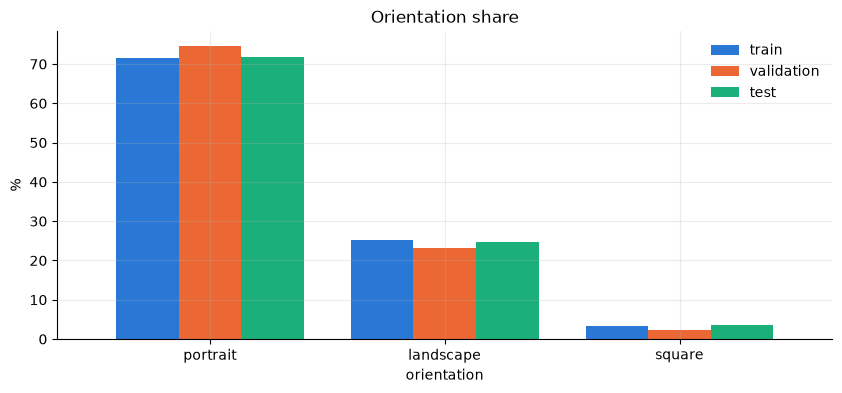

,SMD(valid-train),"KS(valid,train)",SMD(valid-test),"KS(valid,test)"
feature,,,,
aspect_ratio,-0.0471,0.0376,-0.0397,0.0344
megapixels,0.0526,0.0157,0.0682,0.0215
width,-0.0231,0.0248,-0.0122,0.0179
height,0.0718,0.0376,0.0756,0.0344


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hist3("aspect_ratio", bins=60, title="Aspect ratio (width / height) — log scale", ax=axes[0], log=True)
hist3("megapixels", bins=60, title="Image size (megapixels) — log scale", ax=axes[1], log=True)
plt.tight_layout(); plt.show()

display(pd.concat({s: frames[s][["width", "height", "megapixels", "aspect_ratio"]].describe().T[["mean", "50%", "min", "max"]] for s in SPLITS}, axis=1).round(3))

sizes = pd.concat({s: (frames[s]["width"].astype(str) + "×" + frames[s]["height"].astype(str)).value_counts(normalize=True) for s in SPLITS}, axis=1).fillna(0)
top_sizes = sizes.loc[sizes["train"].sort_values(ascending=False).head(10).index]
print("해상도 조합 상위 10개 (%)")
display((top_sizes * 100).round(2).rename_axis("W×H"))

orient = share_table("orientation", order=["portrait", "landscape", "square"])
display(orient)
bar_shares(orient, "Orientation share"); plt.show()

display(shift_table(["aspect_ratio", "megapixels", "width", "height"]))

## 3. 밝기 / 대비 / HSV 분포

세 split 의 밝기(brightness), 대비(contrast), 그리고 HSV 각 채널 평균의 분포.
hue 는 원형 평균이라 붉은색 계열이 0°/360° 양 끝에 나뉘어 나타난다.

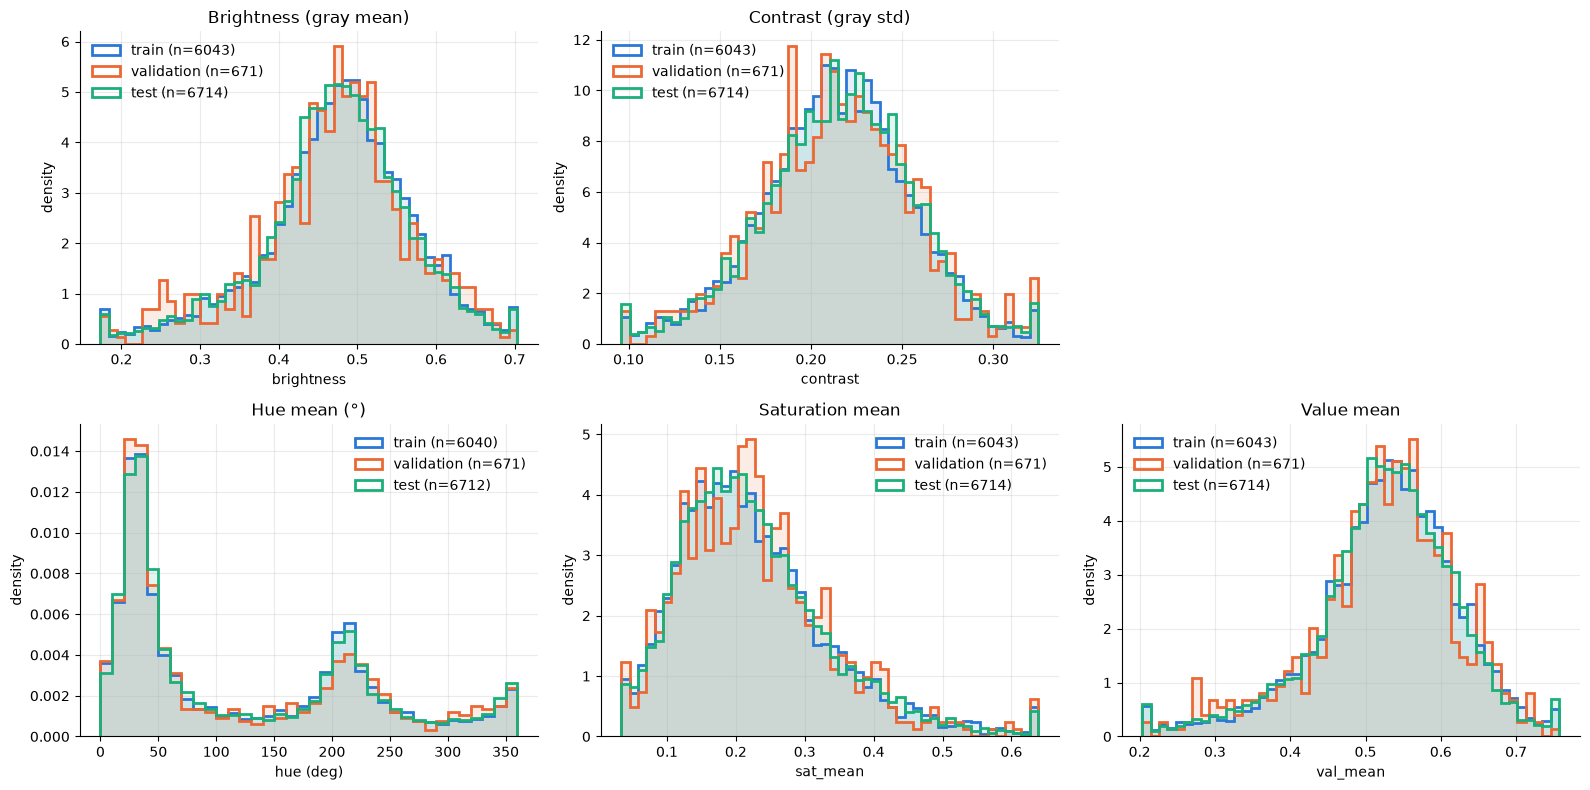

train                    validation                     \
                mean       std      50%       mean       std      50%   
brightness    0.4755    0.0970   0.4815     0.4698    0.0982   0.4780   
contrast      0.2136    0.0409   0.2143     0.2149    0.0428   0.2146   
hue_mean    119.2994  104.0412  63.4186   117.4329  106.6946  56.0320   
sat_mean      0.2260    0.1115   0.2072     0.2294    0.1124   0.2156   
val_mean      0.5283    0.0961   0.5350     0.5230    0.0965   0.5311   

                test                     
                mean       std      50%  
brightness    0.4720    0.0955   0.4768  
contrast      0.2152    0.0421   0.2165  
hue_mean    119.7558  105.5570  63.0238  
sat_mean      0.2261    0.1087   0.2088  
val_mean      0.5248    0.0959   0.5315

,SMD(valid-train),"KS(valid,train)",SMD(valid-test),"KS(valid,test)"
feature,,,,
brightness,-0.0579,0.0340,-0.0224,0.0288
contrast,0.0310,0.0271,-0.0087,0.0264
hue_mean,-0.0177,0.0344,-0.0219,0.0407
sat_mean,0.0303,0.0460,0.0296,0.0376
val_mean,-0.0553,0.0294,-0.0188,0.0248


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
hist3("brightness", title="Brightness (gray mean)", ax=axes[0, 0])
hist3("contrast",   title="Contrast (gray std)",    ax=axes[0, 1])
axes[0, 2].axis("off")
hist3("hue_mean", bins=36, clip_q=1.0, title="Hue mean (°)", xlabel="hue (deg)", ax=axes[1, 0])
hist3("sat_mean", title="Saturation mean", ax=axes[1, 1])
hist3("val_mean", title="Value mean", ax=axes[1, 2])
plt.tight_layout(); plt.show()

hsv_cols = ["brightness", "contrast", "hue_mean", "sat_mean", "val_mean"]
display(pd.concat({s: frames[s][hsv_cols].describe().T[["mean", "std", "50%"]] for s in SPLITS}, axis=1).round(4))
display(shift_table(hsv_cols))

## 4. 질문 / 선지 길이 분포

`common.text_metrics` 기준: 질문 글자 수·어절 수, 보기 4개의 평균·최대·합계 글자 수. 여기에 `question + 보기 4개` 전체 프롬프트 글자 수를 더한다.

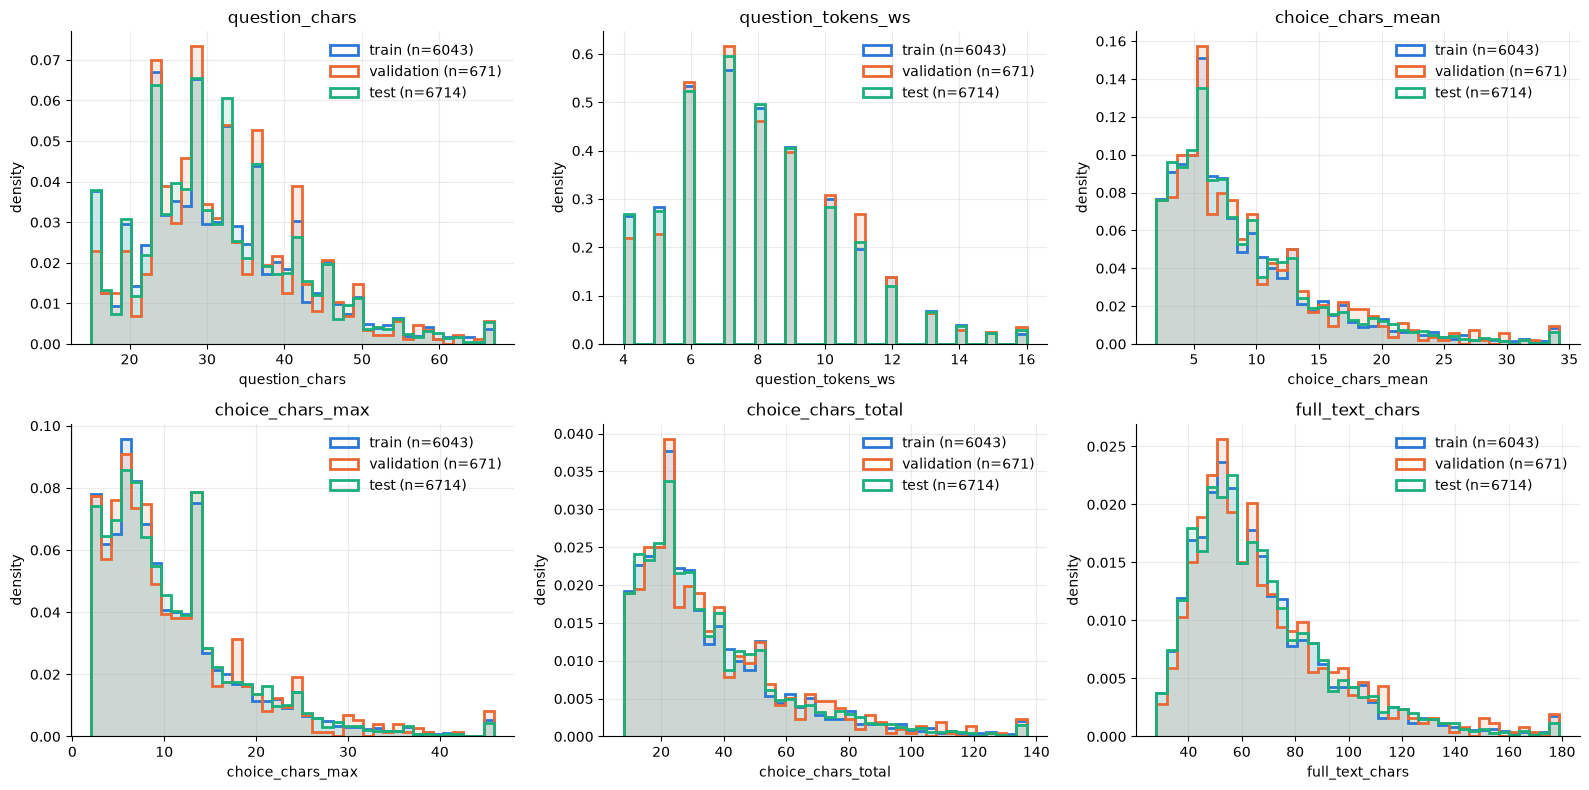

train               validation                 test        \
                     mean   50%     max       mean    50%    max   mean   50%   
question_chars      31.78  30.0  107.00      32.26  30.00   87.0  31.74  30.0   
question_tokens_ws   7.85   8.0   21.00       8.05   8.00   22.0   7.85   8.0   
choice_chars_mean    8.86   7.0   76.75       9.04   7.25   55.0   8.84   7.0   
choice_chars_max    10.97   9.0  109.00      11.15   9.00   87.0  10.95   9.0   
choice_chars_total  35.44  28.0  307.00      36.18  29.00  220.0  35.38  28.0   
full_text_chars     67.23  60.0  371.00      68.44  61.00  305.0  67.12  61.0   

                           
                      max  
question_chars      102.0  
question_tokens_ws   27.0  
choice_chars_mean    62.0  
choice_chars_max     71.0  
choice_chars_total  248.0  
full_text_chars     283.0

,SMD(valid-train),"KS(valid,train)",SMD(valid-test),"KS(valid,test)"
feature,,,,
question_chars,0.0470,0.0428,0.0513,0.0379
question_tokens_ws,0.0750,0.0305,0.0761,0.0301
choice_chars_mean,0.0291,0.0300,0.0325,0.0181
choice_chars_max,0.0216,0.0165,0.0251,0.0136
choice_chars_total,0.0291,0.0300,0.0325,0.0181
full_text_chars,0.0423,0.0235,0.0471,0.0264


In [7]:
TEXT_COLS = ["question_chars", "question_tokens_ws", "choice_chars_mean", "choice_chars_max", "choice_chars_total", "full_text_chars"]
for s in SPLITS:
    tm = text_metrics(frames[s], s).set_index("id")
    tm["full_text_chars"] = tm["question_chars"] + tm["choice_chars_total"]
    frames[s] = frames[s].drop(columns=[c for c in tm.columns if c in frames[s].columns]).join(tm, on="id")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, f in zip(axes.ravel(), TEXT_COLS):
    hist3(f, bins=40, ax=ax)
plt.tight_layout(); plt.show()

display(pd.concat({s: frames[s][TEXT_COLS].describe().T[["mean", "50%", "max"]] for s in SPLITS}, axis=1).round(2))
display(shift_table(TEXT_COLS))

## 5. 질문 유형 분포

`common.question_type` 의 정규식 규칙(전화번호·가격·수량·날짜·색상·위치·메뉴·인물·문자읽기·기타)으로 유형을 매기고 split 별 비율을 비교한다.
마지막에 total variation 거리(범주 비율 차이의 절반 합, 0~1)로 요약한다.

,train,validation,test
question_type,,,
문자·간판 읽기,34.75,34.87,34.52
기타,16.17,16.10,16.64
가격·금액,13.77,14.46,13.43
위치·방향,9.15,8.94,9.43
메뉴·상품,9.07,8.94,9.12
날짜·시간,5.13,4.62,4.96
전화번호,5.10,4.17,4.41
색상,4.35,5.66,4.93
인물·대상,1.37,0.89,1.56


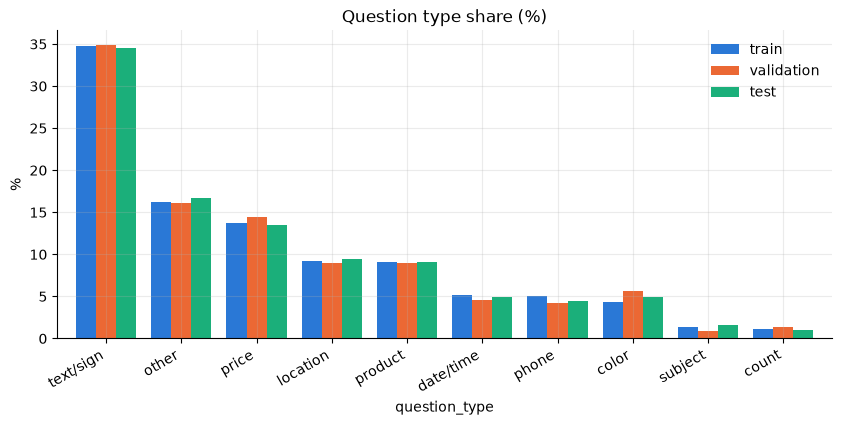

total variation | valid vs train: 0.0232 | valid vs test: 0.0245 | train vs test: 0.0156


In [8]:
type_order = list(frames["train"]["question_type"].value_counts().index)
types = share_table("question_type", order=type_order)
display(types)
TYPE_EN = {"전화번호": "phone", "가격·금액": "price", "수량·계수": "count", "날짜·시간": "date/time", "색상": "color",
           "위치·방향": "location", "메뉴·상품": "product", "인물·대상": "subject", "문자·간판 읽기": "text/sign", "기타": "other"}
bar_shares(types.rename(index=TYPE_EN), "Question type share (%)", rotate=30); plt.show()


def total_variation(a, b):
    labels = sorted(set(a.index) | set(b.index))
    p = a.reindex(labels, fill_value=0).to_numpy(float); p /= p.sum()
    q = b.reindex(labels, fill_value=0).to_numpy(float); q /= q.sum()
    return float(0.5 * np.abs(p - q).sum())


counts = {s: frames[s]["question_type"].value_counts() for s in SPLITS}
print("total variation | valid vs train:", round(total_variation(counts["validation"], counts["train"]), 4),
      "| valid vs test:", round(total_variation(counts["validation"], counts["test"]), 4),
      "| train vs test:", round(total_variation(counts["train"], counts["test"]), 4))

## 요약

위 `shift_table` 값이 모두 |SMD| < 0.1, KS < 0.05 이고 유형 total variation 이 0.03 이하면 validation 은 train·test 와 같은 분포로 보고,
validation 정확도를 test 점수의 추정치로 쓴다. (검증 671문항 기준 정확도 표준오차는 약 ±1.5%p 이므로 그보다 작은 차이는 우연일 수 있다.)